# Notebook para el ejercicio 2 del primer boletín

In [1]:
using DelimitedFiles
using Statistics
using Flux
using Flux.Losses


## *Parte 1*: Implementar One Hot Enconding

In [2]:
function oneHotEncoding(feature:: AbstractArray{<:Any, 1}, classes:: AbstractArray{<:Any, 1})

    num_classes = length(classes)

    if num_classes <= 2
        oneHot = reshape([feature.==classes[1]], :, 1)
    else
        oneHot = Matrix{Bool}(undef, length(feature), num_classes)
        for i in 1:num_classes
            oneHot[:, i] = feature .== classes[i]
        end
    end

    return oneHot
end

oneHotEncoding (generic function with 1 method)

### Overload de oneHotEncoding para diferentes situaciones

In [3]:
function oneHotEncoding(feature:: AbstractArray{<:Any, 1}) 
    
    return oneHotEncoding(feature, unique(feature))
end

oneHotEncoding (generic function with 2 methods)

In [4]:
function oneHotEncoding(feature:: AbstractArray{Bool, 1}) 
    
    return reshape(feature, :, 1)
end

oneHotEncoding (generic function with 3 methods)

## *Parte 2*: Normalización de datos

In [5]:
function calculateMinMaxNortmalizationParameters(data:: AbstractArray{<:Real, 2})
    
    mins = minimum(data, dims=1)
    maxs = maximum(data, dims=1)
    return (mins, maxs)
end

calculateMinMaxNortmalizationParameters (generic function with 1 method)

In [6]:
function calculateZeroMeanNortmalizationParameters(data:: AbstractArray{<:Real, 2})
    
    meanValues = mean(data, dims=1)
    stdValues = std(data, dims=1)
    return (meanValues, stdValues)
end

calculateZeroMeanNortmalizationParameters (generic function with 1 method)

In [7]:
function normalizeMinMax!(data:: AbstractArray{<: Real, 2}, normValues:: NTuple{2, AbstractArray{<: Real, 2}})
    
    mins, maxs = normValues
    data .= (data .- mins) ./ (maxs .- mins)
end

normalizeMinMax! (generic function with 1 method)

In [8]:
function normalizeMinMax!(data:: AbstractArray{<: Real, 2})
    
    normValues = calculateMinMaxNortmalizationParameters(data)
    normalizeMinMax!(data, normValues)
end

normalizeMinMax! (generic function with 2 methods)

In [9]:
function normalizeMinMax(data:: AbstractArray{<: Real, 2}, normValues:: NTuple{2, AbstractArray{<: Real, 2}})
    
    mins, maxs = normValues
    normalized_data = copy(data)
    normalized_data .= (normalized_data .- mins) ./ (maxs .- mins)
    return normalized_data
end

normalizeMinMax (generic function with 1 method)

In [68]:
function normalizeMinMax(data:: AbstractArray{<: Real, 2})
    
    normValues = calculateMinMaxNortmalizationParameters(data)
    normalized_data = copy(data)
    return normalizeMinMax(normalized_data, normValues)
end

normalizeMinMax (generic function with 2 methods)

In [11]:
function normalizeZeroMean!(data:: AbstractArray{<: Real, 2}, normValues:: NTuple{2, AbstractArray{<: Real, 2}})
    
    meanValues, stdValues = normValues
    data .= (data .- meanValues) ./ stdValues
    data[:, vec(stdValues.==0)] .= 0;
end

normalizeZeroMean! (generic function with 1 method)

In [12]:
function normalizeZeroMean!(data:: AbstractArray{<: Real, 2})
    
    norm_values = calculateZeroMeanNortmalizationParameters(data)
    normalizeZeroMean!(data, norm_values)
end

normalizeZeroMean! (generic function with 2 methods)

In [13]:
function normalizeZeroMean(data:: AbstractArray{<: Real, 2}, normValues:: NTuple{2, AbstractArray{<: Real, 2}})
    
    meanValues, stdValues = normValues
    normalized_data = copy(data)
    normalized_data .= (normalized_data .- meanValues) ./ stdValues
    normalized_data[:, vec(stdValues.==0)] .= 0;
    return normalized_data
end

normalizeZeroMean (generic function with 1 method)

In [14]:
function normalizeZeroMean(data:: AbstractArray{<: Real, 2})
    
    norm_values = calculateZeroMeanNortmalizationParameters(data)
    normalized_data = copy(data)
    return normalizeZeroMean(normalized_data, norm_values)
end

normalizeZeroMean (generic function with 2 methods)

## *Parte 3*: Clasificar outputs 

In [15]:
function classifyOutputs(outputs:: AbstractArray{<: Real, 1}, threshold = 0.5)
    
    return outputs .>= threshold
end

classifyOutputs (generic function with 2 methods)

In [16]:
function classifyOutputs(outputs:: AbstractArray{<: Real, 2}, threshold = 0.5)

    dims = size(outputs)
    
    if dims[2] == 1
        bool_vector = classifyOutputs(outputs[:], threshold)
        return reshape(bool_vector, :, 1)
    else
        outputs = falses(dims)
        (_, indicesMaxEachInstance) = findmax(outputs, dims=2) # Obtener el índice de la clase con la probabilidad más alta
        outputs[indicesMaxEachInstance] .= true
        return outputs  
    end
end

classifyOutputs (generic function with 4 methods)

## *Parte 4*: Implementar métricas sobre los resultados de la ANN

In [17]:
# Primer caso: se pasa un vector booleano para target y otro para outputs

function accuracy(targets:: AbstractArray{Bool, 1}, outputs:: AbstractArray{Bool, 1})
    
    return mean(targets .== outputs)
end

accuracy (generic function with 1 method)

In [18]:
# Segundo caso: se pasa una matriz de booleanos para targets y otra para outputs

function accuracy(targets:: AbstractArray{Bool, 2}, outputs:: AbstractArray{Bool, 2})

    dims = size(targets)

    if dims[2] == 1
        return accuracy(targets[:], outputs[:])

    elseif dims[2] > 2

        classComparison = targets .== outputs # Si la clase ha sido predicha correctamente, todos los elementos de la fila serán verdaderos (true == true, false == false, etc.)
        correctClassifications = all(classComparison, dims=2) 
        return mean(correctClassifications)

    end
    
    return mean(targets .== outputs)
end

accuracy (generic function with 2 methods)

In [19]:
# Tercer caso: se pasa un vector de targets booleanos y un vector de probabilidades como salida de la ANN.

function accuracy(targets:: AbstractArray{Bool, 1}, outputs:: AbstractArray{<: Real, 1}, threshold = 0.5)
    
    return accuracy(targets, outputs .>= threshold)
end

accuracy (generic function with 4 methods)

In [20]:
# Cuarto caso: se pasa una matriz de targets booleanos y una matriz de probabilidades como salida de la ANN.

function accuracy(targets:: AbstractArray{Bool, 2}, outputs:: AbstractArray{<: Real, 2})
    
    dims = size(targets)

    if dims[2] == 1
        return accuracy(targets[:1], outputs[:1])

    elseif dims[2] > 2
        return accuracy(targets, classifyOutputs(outputs))
        
    end
    
    return mean(targets .== outputs)
end

accuracy (generic function with 5 methods)

## *Paso 5*: Crear una ANN

In [50]:
function buildClassANN(numInputs:: Int, topology:: AbstractArray{<:Int, 1}, numOutputs:: Int, transferFunctions::AbstractArray{<:Function,1}=fill(σ, length(topology)))
    
    ann = Chain()
    numInputsLayer = numInputs
    
    # Construir capas ocultas usando las funciones de transferencia correspondientes
    for (numOutputsLayer, transferFunction) in zip(topology, transferFunctions)
        ann = Chain(ann..., Dense(numInputsLayer, numOutputsLayer, transferFunction))
        numInputsLayer = numOutputsLayer
    end

    if numOutputs == 1 # problema de clasificacion binaria
        ann = Chain(ann..., Dense(numInputsLayer, numOutputs, σ));
    else # problema de clasificación multiclase
        ann = Chain(ann..., Dense(numInputsLayer, numOutputs), softmax);
    end

    return ann
end

buildClassANN (generic function with 2 methods)

## *Paso 6*: Train ANN

In [48]:
function trainClassANN(topology:: AbstractArray{<: Int, 1}, dataset:: Tuple{AbstractArray{<: Real, 2}, AbstractArray{Bool, 2}}, transferFunctions::AbstractArray{<:Function,1} = fill(σ, length(topology)), maxEpochs:: Int = 1000, minLoss:: Real = 0.0, learningRate:: Real = 0.01)

    inputs, targets = dataset
    inputs = Float32.(inputs')  # Convertir a Float32 y trasponer
    targets = (targets')   # Trasponer
    
    numInputs = size(inputs, 1)
    numOutputs = size(targets, 1)
    
    ann = buildClassANN(numInputs, topology, numOutputs, transferFunctions) # build ANN
    loss(model, x,y) = (size(y,1) == 1) ? Losses.binarycrossentropy(model(x),y) : Losses.crossentropy(model(x),y) # loss function
    opt_state = Flux.setup(ADAM(learningRate), ann) # optimizer

    losses = Float32[] # losses array
    push!(losses, loss(ann, inputs, targets)) # append iteration 0 loss 
    
    for epoch in 1:maxEpochs
        
        Flux.train!(loss, ann, [(inputs, targets)], opt_state)
        current_loss = loss(ann, inputs, targets)
        push!(losses, current_loss)
        
        if current_loss ≤ minLoss
            break
        end
    end
    
    return ann, losses
end

trainClassANN (generic function with 10 methods)

In [29]:
function trainClassANN(topology:: AbstractArray{<: Int, 1}, dataset:: Tuple{AbstractArray{<: Real, 2}, AbstractArray{Bool, 1}}, transferFunctions::AbstractArray{<:Function,1} = fill(σ, length(topology)), maxEpochs:: Int = 1000, minLoss:: Real = 0.0, learningRate:: Real = 0.01)

    inputs, targets = dataset
    reshape!(targets, :, 1) 
    return trainClassANN(topology, (inputs, targets), transferFunctions, maxEpochs, minLoss, learningRate)
    
end

trainClassANN (generic function with 10 methods)

## *Final Step*: Basic Pipeline

In [85]:
dataset = readdlm("iris.data", ',')

# Asegurarnos de que los inputs son AbstractArray{<:Real, 2}
inputs = convert(AbstractArray{Float32, 2}, normalizeZeroMean(Float32.(dataset[:, 1:4])))

# Asegurarnos de que outputs es AbstractArray{Bool, 2}
outputs = convert(AbstractArray{Bool, 2}, oneHotEncoding(dataset[:, 5]))

# Asegurarnos de que topology es AbstractArray{<:Int, 1}
topology = convert(AbstractArray{Int, 1}, [8, 4])

# Para debuggear, vamos a imprimir los tipos
println("Type of inputs: ", typeof(inputs))
println("Type of outputs: ", typeof(outputs))
println("Type of topology: ", typeof(topology))

# Llamada a la función
ann, loss = trainClassANN(topology, (inputs, outputs), [σ, σ], 1000, 0.001, 0.1)


Type of inputs: Matrix{Float32}
Type of outputs: Matrix{Bool}
Type of topology: Vector{Int64}


(Chain(Dense(4 => 8, σ), Dense(8 => 4, σ), Dense(4 => 3), softmax), Float32[1.3685353, 1.1420726, 1.0424494, 1.0105103, 0.9844215, 0.9422295, 0.88469225, 0.8193753, 0.75440687, 0.69584775  …  0.0010386276, 0.0010339203, 0.0010292418, 0.0010246044, 0.0010199976, 0.0010154331, 0.0010109013, 0.001006411, 0.0010019469, 0.0009975316])

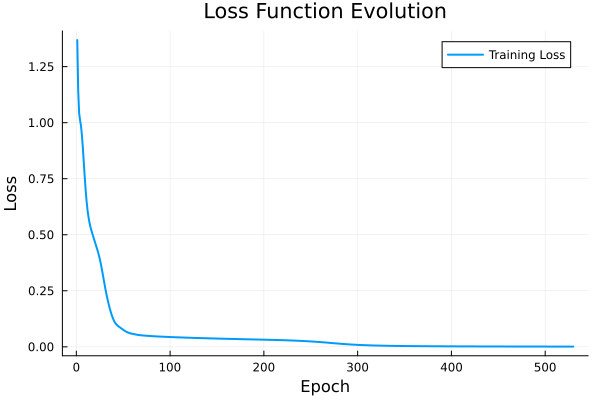

In [86]:
using Plots

function plotLoss(losses)
    plot(losses, 
         label="Training Loss", 
         xlabel="Epoch", 
         ylabel="Loss",
         title="Loss Function Evolution",
         linewidth=2,
         legend=:topright)
end

# Usar la función
plotLoss(loss)

#0.0009752035